# Chapter 2: Important Distributions


In this notebook, we explore several important probability distributions
that frequently appear in statistics and data science.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom


## Randomness and Variability

In [2]:
# Simulate rolling a die 100 times

dice_rolls = np.random.randint(1, 7, 100)

dice_rolls[:20]


array([2, 3, 4, 4, 3, 3, 3, 2, 1, 4, 3, 2, 6, 2, 4, 4, 2, 6, 1, 1])

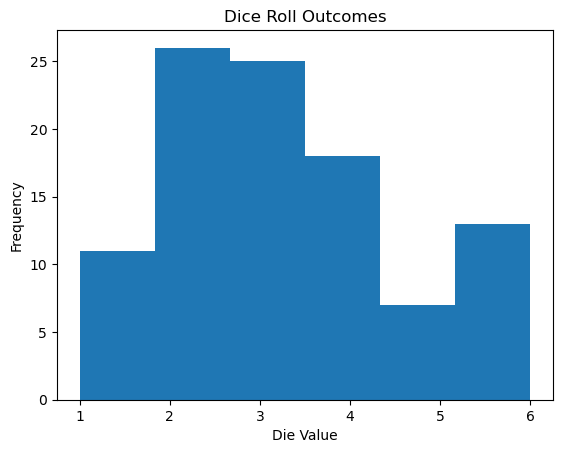

In [3]:
# Visualize the results

plt.hist(dice_rolls, bins=6)

plt.title("Dice Roll Outcomes")

plt.xlabel("Die Value")
plt.ylabel("Frequency")

plt.show()


## The Normal Distribution

In [4]:
# Generate data from a normal distribution

data = np.random.normal(loc=70, scale=10, size=1000)


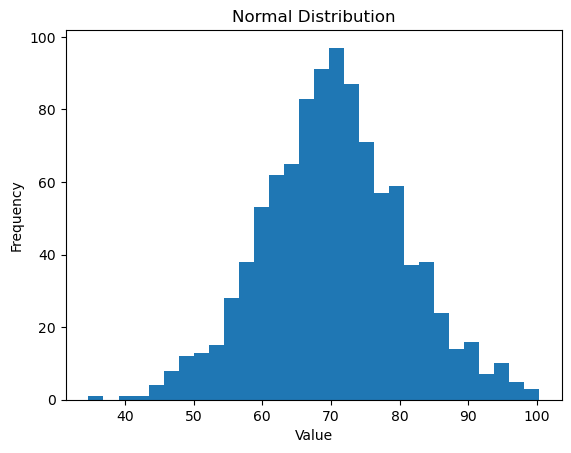

In [5]:
# Visualize the distribution

plt.hist(data, bins=30)

plt.title("Normal Distribution")

plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()


In [6]:
# Mean and standard deviation

print("Mean:", round(np.mean(data), 2))
print("Standard deviation:", round(np.std(data), 2))


Mean: 70.4
Standard deviation: 10.26


## The Empirical Rule

In [7]:
# Percentage within one standard deviation

mean = np.mean(data)
std = np.std(data)

within_one_std = data[
    (data >= mean - std) &
    (data <= mean + std)
]

percentage = len(within_one_std) / len(data) * 100

print("Percentage within one standard deviation:")
print(round(percentage, 2), "%")


Percentage within one standard deviation:
68.5 %


## Z-Scores

In [8]:
# Exam score example

score = 85
mean = 70
std = 10

z_score = (score - mean) / std

print("Z-score:", z_score)


Z-score: 1.5


## The Binomial Distribution

In [9]:
# Probability of exactly 5 heads
# in 10 coin flips

probability = binom.pmf(5, 10, 0.5)

print(probability)


0.24609375000000003


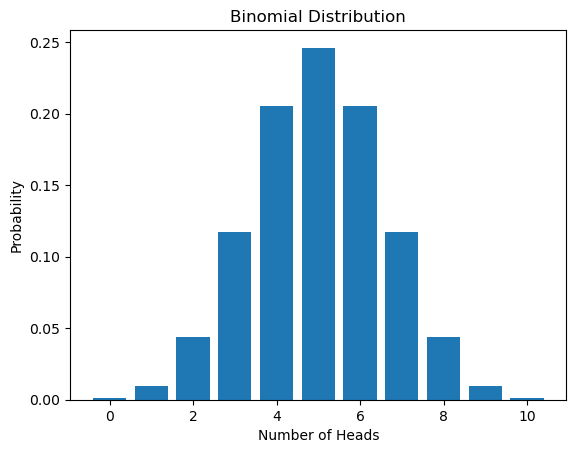

In [10]:
# Possible number of heads in 10 coin flips
x = np.arange(0, 11)

# pmf stands for Probability Mass Function
# It calculates the probability of each outcome

y = binom.pmf(x, 10, 0.5)

plt.bar(x, y)

plt.title("Binomial Distribution")

plt.xlabel("Number of Heads")
plt.ylabel("Probability")

plt.show()

In [11]:
# Mean and standard deviation
# of a binomial distribution

n = 10
p = 0.5

mean = n * p
std = np.sqrt(n * p * (1 - p))

print("Mean:", mean)
print("Standard deviation:", round(std, 2))


Mean: 5.0
Standard deviation: 1.58


# Appendix A: Other Important Distributions

## Poisson Distribution

In [12]:
from scipy.stats import poisson


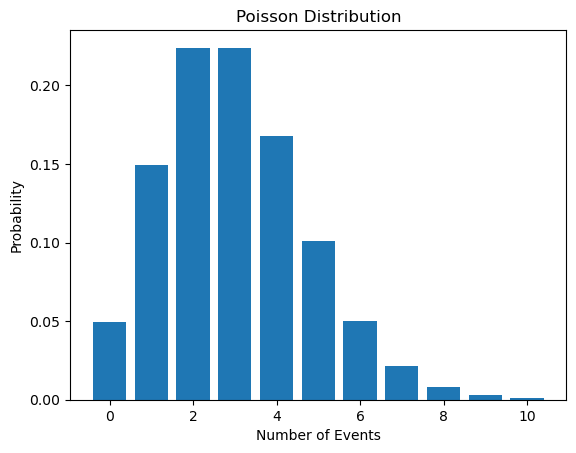

In [13]:
# Number of website visits per minute

x = np.arange(0, 11)

y = poisson.pmf(x, mu=3)

plt.bar(x, y)

plt.title("Poisson Distribution")

plt.xlabel("Number of Events")
plt.ylabel("Probability")

plt.show()


## Exponential Distribution

In [14]:
from scipy.stats import expon


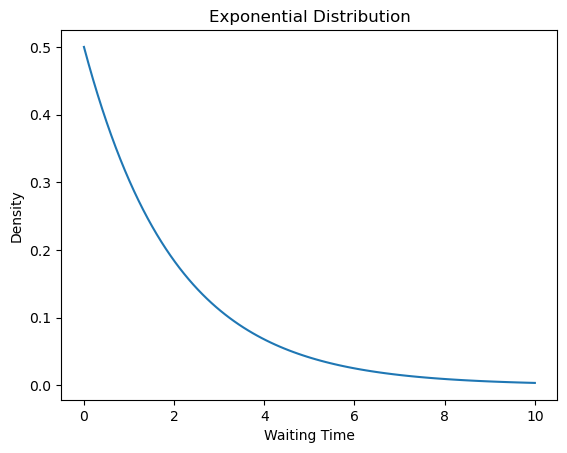

In [15]:
# Waiting time distribution

x = np.linspace(0, 10, 100)

y = expon.pdf(x, scale=2)

plt.plot(x, y)

plt.title("Exponential Distribution")

plt.xlabel("Waiting Time")
plt.ylabel("Density")

plt.show()


## Student's t-Distribution

In [16]:
from scipy.stats import t


In [17]:
# Generate data from a t-distribution

# rvs stands for Random Variates Sampling
# It generates random values from the distribution

data_t = t.rvs(df=5, size=1000)


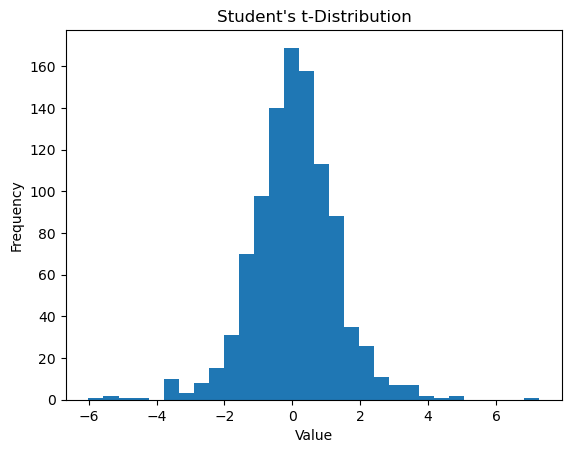

In [18]:
# Visualize the distribution

plt.hist(data_t, bins=30)

plt.title("Student's t-Distribution")

plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()


## Chi-Square Distribution

In [19]:
from scipy.stats import chi2


In [20]:
# Generate chi-square data

data_chi = chi2.rvs(df=4, size=1000)


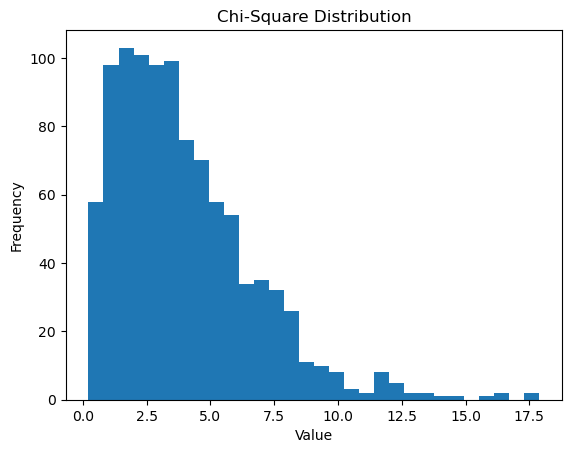

In [21]:
# Visualize the distribution

plt.hist(data_chi, bins=30)

plt.title("Chi-Square Distribution")

plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()


## F-Distribution

The F-distribution arises when comparing two sources of variability. It is commonly used in:

- Analysis of Variance (ANOVA)
- Comparing variances between groups
- Regression model evaluation

The shape of the F-distribution depends on two degrees of freedom parameters. It is always nonnegative and is typically right-skewed.

In [22]:
from scipy.stats import f

In [23]:
# Generate F-distribution data

data_f = f.rvs(dfn=5, dfd=20, size=1000)

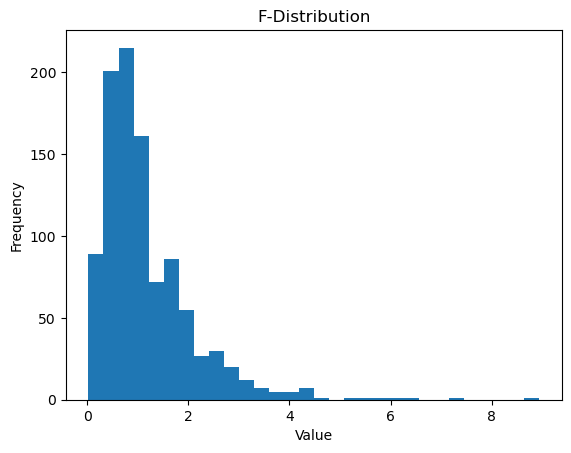

In [24]:
# Visualize the distribution

plt.hist(data_f, bins=30)

plt.title("F-Distribution")

plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

# Appendix B: Monte Carlo Simulation

Monte Carlo simulation uses repeated random experiments to estimate probabilities and explore uncertainty.

Instead of solving a probability problem only with formulas, we allow the computer to simulate many possible outcomes and then study the results.


## A Coin-Flipping Example

Suppose a fair coin is flipped 20 times. We want to estimate the probability of obtaining at least 15 heads.

We already know this problem can be solved using the binomial distribution. Here, we use simulation instead.


In [25]:
# Monte Carlo simulation: 20 coin flips

rng = np.random.default_rng(42)

num_simulations = 10000
num_flips = 20

# Simulate coin flips
# 1 represents heads, 0 represents tails
coin_flips = rng.integers(0, 2, size=(num_simulations, num_flips))

# Count heads in each simulation
heads_count = coin_flips.sum(axis=1)

# Estimate the probability of getting at least 15 heads
prob_at_least_15 = np.mean(heads_count >= 15)

print("Estimated probability of at least 15 heads:")
print(round(prob_at_least_15, 4))


Estimated probability of at least 15 heads:
0.0212


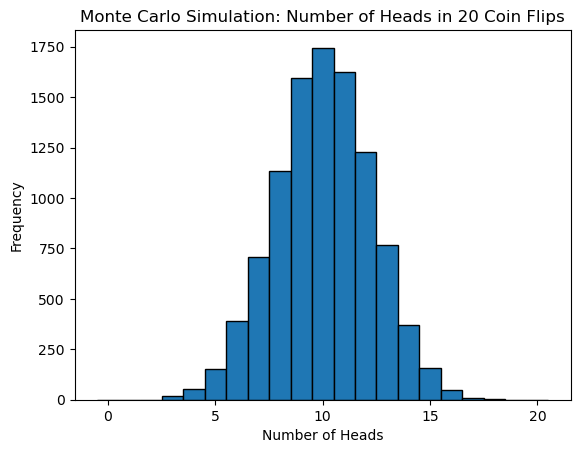

In [26]:
# Visualize the simulated number of heads

plt.hist(heads_count, bins=np.arange(-0.5, num_flips + 1.5, 1), edgecolor='black')

plt.title("Monte Carlo Simulation: Number of Heads in 20 Coin Flips")
plt.xlabel("Number of Heads")
plt.ylabel("Frequency")

plt.show()


The simulated probability will not be exactly the same every time because the simulation itself is random.

However, as the number of simulations becomes large, the estimate usually becomes more stable.


In [27]:
# Compare different numbers of simulations

simulation_sizes = [100, 1_000, 10_000, 100_000]

for size in simulation_sizes:
    flips = rng.integers(0, 2, size=(size, num_flips))
    heads = flips.sum(axis=1)
    estimated_probability = np.mean(heads >= 15)
    print(f"Simulations: {size:>6} | Estimated probability: {estimated_probability:.4f}")


Simulations:    100 | Estimated probability: 0.0400
Simulations:   1000 | Estimated probability: 0.0100
Simulations:  10000 | Estimated probability: 0.0184
Simulations: 100000 | Estimated probability: 0.0207


## Estimating Investment Risk

Monte Carlo simulation is also useful when we want to understand risk.

Suppose two investments have the same expected annual return, but different levels of variability:

- Investment A: mean return = 10%, standard deviation = 10%
- Investment B: mean return = 10%, standard deviation = 30%

We simulate many possible annual returns for each investment and compare the results.


In [28]:
# Monte Carlo simulation: investment returns

num_simulations = 10000

investment_A = rng.normal(loc=0.10, scale=0.10, size=num_simulations)
investment_B = rng.normal(loc=0.10, scale=0.30, size=num_simulations)

prob_loss_A = np.mean(investment_A < 0)
prob_loss_B = np.mean(investment_B < 0)

prob_high_return_A = np.mean(investment_A > 0.25)
prob_high_return_B = np.mean(investment_B > 0.25)

print("Probability of losing money:")
print("Investment A:", round(prob_loss_A, 4))
print("Investment B:", round(prob_loss_B, 4))

print("\nProbability of earning more than 25%:")
print("Investment A:", round(prob_high_return_A, 4))
print("Investment B:", round(prob_high_return_B, 4))


Probability of losing money:
Investment A: 0.1582
Investment B: 0.3684

Probability of earning more than 25%:
Investment A: 0.0689
Investment B: 0.3072


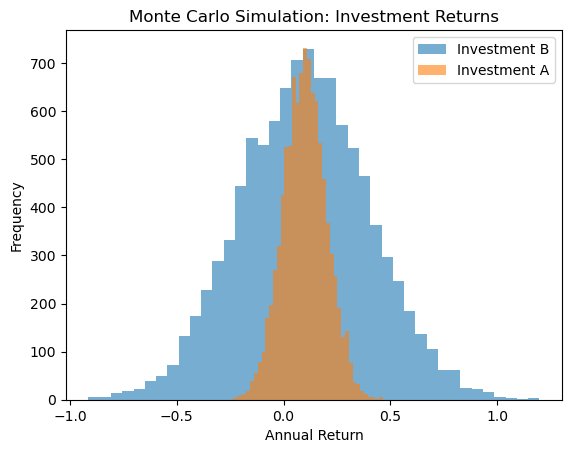

In [29]:
# Visualize the simulated investment returns


plt.hist(investment_B, bins=40, alpha=0.6, label="Investment B")
plt.hist(investment_A, bins=40, alpha=0.6, label="Investment A")

plt.title("Monte Carlo Simulation: Investment Returns")
plt.xlabel("Annual Return")
plt.ylabel("Frequency")
plt.legend()

plt.show()


Both investments have the same expected return, but the simulations show that they have very different risk profiles.

Investment B has a wider range of possible outcomes. It may produce very high returns in some simulations, but it also has a greater chance of producing losses.

This illustrates one of the main benefits of Monte Carlo simulation: it helps us understand not only what is expected, but also what is possible.


## Why Simulation Is Useful

Monte Carlo simulation is helpful because many real-world problems involve uncertainty and many possible outcomes.

Simulation allows analysts to explore questions such as:

- What might happen?
- How likely is each outcome?
- How much risk is involved?
- How sensitive are the results to randomness?

For this reason, Monte Carlo simulation is widely used in finance, engineering, operations research, project planning, and data science.
